# Versuchsaufbau (Aufgabe1)
Der Versuchsaufbau von Aufgabe 1 war einne aukustische Bank. Wo zwei Schieber mit einem Sender und Empfänger verschoben werden können. Der Sender ist mit einem Signalerzeuger verbunden |  während der Empfänger mit dem Oszilloskop und dem Spannungsmesser verbunden war.
Für die verschiedenen Teilaufgaben in der 1ten Aufgabe wurde verschieden Vorgegangen.
b) Hierfür wurde für einen festen Abstand |  für verschiedene Frequenzen die Amplitude über das Messgerät gemessen um herauszufinden wann die Amplitude der Frequenz am größten beim Empfänger ist. Die ermittelte Resonanzfrequenz wurde in allen anderen Versuchen dann benutzt.
c) Für c) wurde die Amplitude für eine feste Frequenz, der Empfänger immer weiter von dem Sender weggeschoben. Es wird eine $1/r$ abhängigkeit erwartet, wegen des kugelwellen Charakters der Schallwelle.
d) Es wurde für bestimmte Lissajous-Figuren, die eine gewisse Phasendifferenz beschreiben der Abstand zwischen Sender und Empfänger gemessen. Dabei war die Frequenz fest und nur der Abstand wurde geändert.
e) FÜr die letzte Teilaufgabe in 1 wurde für eine feste Frequenz für verschiedene Abstände die Zeit gemessen, die das Signal vom Sender zum Empfänger braucht. Dabei wird die Schallgeschwindigkeit als geradlinige gleichmäßige Bewegung angenommen.

# Teilaufgabe B

## Bestimmen der Resonanzfrequenz

Wie schon beschrieben, bestand der Versuchsaufbau aus einem Ultraschallsender und Empfänger. Der Sender war mit einem Funktionsgenerator verbunden, über den wir die Wechselspannung einstellen konnten, mithilfe der Sender die Schallwellen ausgesendet hat. In der Aufgabe war es das Ziel, die Resonanzfrequenz zu bestimmen. Bei der Resonanzfrequenz ist die Amplitude der Schwingung beim Empfänger für den gleichen Abstand am höchsten. Dafür haben wir mithilfe eines Tischmultimeters am Empfänger die Amplitude der Wechselspannung abgelesen und am Funktionsgenerator immer wieder die Frequenz verändert.

Im ersten Schritt wurde versucht grob herauszufinden |  in welchem Bereich sich die Frequenz befindet. Dabei war die Amplitude bei 41 kHz am größten |  weshalb für die Messung dann zwischen 40 und 42 kHz genauer eingestellt wurde. Da die Spannung am Multimeter sich die ganze Zeit verändert hat |  wurde versucht immer einen der mittleren Werte zu nehmen. Dabei kamen die folgenden Messerte heraus:
| f [kHz] | U [mV] |
|---------|--------|
| 40.00   | 60.50  |
| 40.10   | 71.30  |
| 40.20   | 77.70  |
| 40.30   | 88.30  |
| 40.40   | 97.80  |
| 40.50   | 112.10 |
| 40.60   | 121.40 |
| 40.70   | 142.60 |
| 40.80   | 157.20 |
| 40.90   | 175.10 |
| 40.91   | 180.40 |
| 40.92   | 182.40 |
| 40.93   | 182.90 |
| 40.94   | 185.70 |
| 40.95   | 188.80 |
| 40.96   | 194.10 |
| 40.97   | 195.20 |
| 40.98   | 192.30 |
| 40.99   | 191.90 |
| 41.00   | 191.10 |
| 41.01   | 197.10 |
| 41.02   | 196.80 |
| 41.03   | 196.10 |
| 41.04   | 192.50 |
| 41.05   | 193.40 |
| 41.10   | 192.40 |
| 41.20   | 181.40 |
| 41.30   | 149.70 |
| 41.40   | 113.70 |
| 41.50   | 87.70  |
| 41.60   | 63.60  |
| 41.70   | 51.90  |

Während den anderen Aufgaben haben wir also 41,01 kHz als Resonanzfrequenz genutzt, die genaue wurde dann beim fitten der Funktion versucht zu finden.

Asymmetrischer Fit:
U₀         = 180.72 mV
f₀         = 41.11471 kHz
Symmetrischer Fit:
U₀         = 159.33 mV
f₀         = 40.99943 kHz


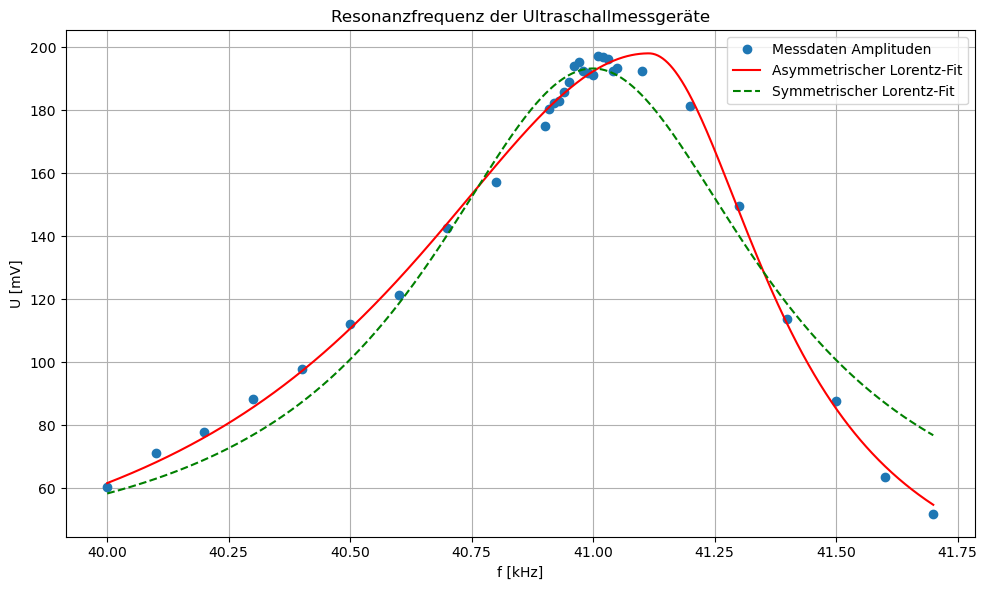

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Daten einlesen
df = pd.read_csv("./daten/Aufgabe1b.csv")
df.columns = ["f [kHz]", "U [mV]"]
f_kHz = df["f [kHz]"].values
U_mV = df["U [mV]"].values

# --------------------------
# Asymmetrischer Lorentz-Fit
# --------------------------
def asym_lorentz(f, U0, f0, gamma_L, gamma_R, offset):
    gamma = np.where(f < f0, gamma_L, gamma_R)
    return U0 * (0.5 * gamma)**2 / ((f - f0)**2 + (0.5 * gamma)**2) + offset

# Startwerte
U0_guess = U_mV.max() - U_mV.min()
f0_guess = f_kHz[np.argmax(U_mV)]
gamma_L_guess = 0.05
gamma_R_guess = 0.1
offset_guess = U_mV.min()

popt_asym, _ = curve_fit(asym_lorentz, f_kHz, U_mV,
                         p0=[U0_guess, f0_guess, gamma_L_guess, gamma_R_guess, offset_guess])

# Fit-Kurve
f_fit = np.linspace(f_kHz.min(), f_kHz.max(), 1000)
U_fit_asym = asym_lorentz(f_fit, *popt_asym)

# --------------------------
# Symmetrischer Lorentz-Fit
# --------------------------
def sym_lorentz(f, U0, f0, gamma, offset):
    return U0 * (0.5 * gamma)**2 / ((f - f0)**2 + (0.5 * gamma)**2) + offset

# Startwerte
gamma_guess = 0.1
popt_sym, _ = curve_fit(sym_lorentz, f_kHz, U_mV,
                        p0=[U0_guess, f0_guess, gamma_guess, offset_guess])

U_fit_sym = sym_lorentz(f_fit, *popt_sym)

# --------------------------
# Ausgabe der Parameter
# --------------------------
print("Asymmetrischer Fit:")
print(f"U₀         = {popt_asym[0]:.2f} mV")
print(f"f₀         = {popt_asym[1]:.5f} kHz")
# print(f"Γ links    = {popt_asym[2]:.5f} kHz")
# print(f"Γ rechts   = {popt_asym[3]:.5f} kHz")
# print(f"Offset     = {popt_asym[4]:.2f} mV\n")

print("Symmetrischer Fit:")
print(f"U₀         = {popt_sym[0]:.2f} mV")
print(f"f₀         = {popt_sym[1]:.5f} kHz")
# print(f"Γ          = {popt_sym[2]:.5f} kHz")
# print(f"Offset     = {popt_sym[3]:.2f} mV")

# --------------------------
# Plot
# --------------------------
plt.figure(figsize=(10, 6))
plt.plot(f_kHz, U_mV, 'o', label='Messdaten Amplituden')
plt.plot(f_fit, U_fit_asym, 'r-', label='Asymmetrischer Lorentz-Fit')
plt.plot(f_fit, U_fit_sym, 'g--', label='Symmetrischer Lorentz-Fit')
plt.xlabel('f [kHz]')
plt.ylabel('U [mV]')
plt.title("Resonanzfrequenz der Ultraschallmessgeräte")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


Beim Plotten der Werte, haben wir auch versucht einen Fit für die Funktion zu finden. Dabei ist aufgefallen, dass ein normaler Lorentz-Fit der normalerweise Resonanzkurven genau darstellt nicht so gut passt. Die Werte waren nicht Symmetrisch ausgehend von der Resonanzfrequenz. Deshalb haben wir auch noch den Fit einer Asymmetrischen Lorentzfunktion probiert, welcher die Werte viel genauer abbildet.

Gründe für ein Asymmetrisches verhalten der Messwerte können zum Beispiel beim Sender/Empfänger oder dem Multimeter liegen. Das Umwandeln des Senders von der Wechselspannung zur Druckwelle könnte beschädigt sein und somit bei höher werdenden Frequenzen unterschiedlich funktionieren. Auch das Multimeter kann beim Ablesen von höheren Frequenzen Probleme mit der Schnelligkeit der Signale haben und somit schlechter die Werte ausgeben.

Laut dem Asymmetrischen Fit, welcher die Messwerte am genauesten darstellt, liegt die Resonanzfrequenz bei 41,115 kHz. In den weiteren Aufgaben wurde trotzdem mit der Frequenz 41,01 kHz gearbeitet, da diese aus den Messwerten korrekt erschien.

## Fehlerbetrachtung
Die größten Messungenauigkeiten an den Messwerten gab es beim ablesen der Spannung am Multimeter. Dieses hat sehr stark beim ausgeben der Werte geschwankt, häufig mit einer Spanne von bis zu 6 mV. Da wir immer versucht haben, den Mittelwert abzulesen, liegt der Bereich der Messwerte bei $\pm 3$ mV.

# Teilaufgabe C
## Messen des Schallsignals als Funktion des Abstands

Beim zweiten Aufgabeteil, wurden bei der Resonanzfrequenz die Amplituden für verschiedene Abstände zwischen Sender und Empfänger gemessen. Dabei waren die Abfälle größer, je kleiner der Abstand war, weshalb wir für geringe Abstände mehr Messwerte genommen haben. Die folgenden Messwerte wurden dabei dokumentiert:
| s [cm] | U [mV] |
|--------|--------|
| 10     | 467.90 |
| 11     | 617.10 |
| 12     | 692.20 |
| 13     | 327.10 |
| 14     | 297.80 |
| 15     | 375.80 |
| 16     | 213.60 |
| 17     | 223.80 |
| 18     | 241.30 |
| 19     | 173.20 |
| 20     | 175.40 |
| 25     | 124.90 |
| 30     | 111.40 |
| 35     | 84.70  |
| 40     | 72.20  |
| 45     | 64.50  |
| 50     | 61.90  |
| 55     | 48.80  |
| 60     | 57.80  |
| 65     | 44.40  |
| 70     | 39.90  |
| 75     | 31.70  |
| 80     | 21.40  |
| 85     | 34.00  |
| 90     | 37.20  |

Die genutzte Frequenz war 41,01 kHz und auch diese Messreihe wurde geplottet und versucht einen guten Fit zu finden um die Abhängigkeit zu bestimmen.

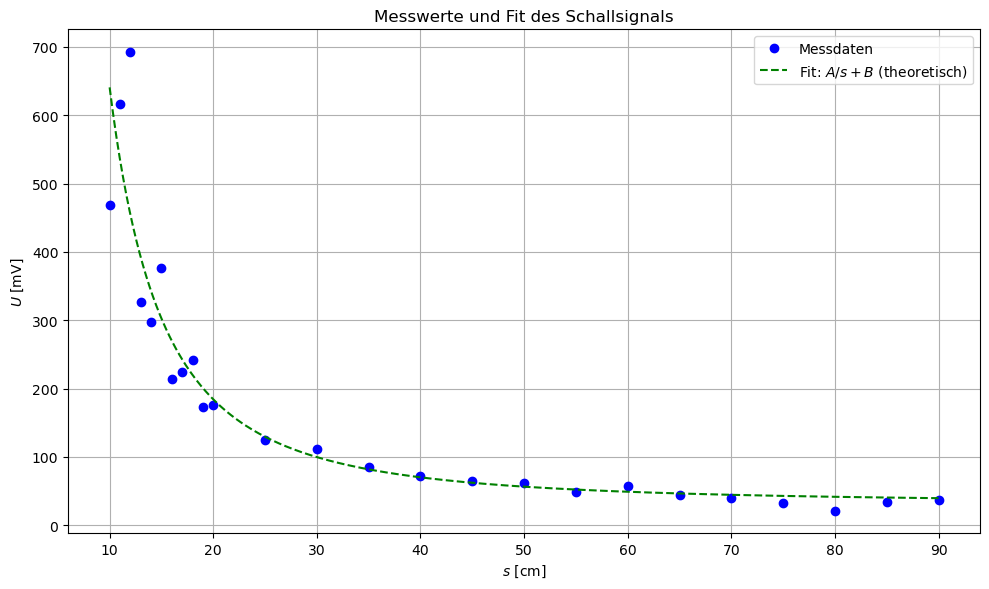

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Daten laden
df = pd.read_csv("./daten/Aufgabe1c.csv")
df.columns = ["s [cm]", "U [mV]"]
s = df["s [cm]"].values
U = df["U [mV]"].values

# --- Modell 1: Theoretisch (1/s + Offset) ---
def model_theory(s, A, B):
    return A / s**2 + B


# Fit 1: theoretisch
popt_theory, _ = curve_fit(model_theory, s, U, p0=[1000, 0])
U_theory_fit = model_theory(s, *popt_theory)



# Fit-Kurven für glatte Linie
s_fit = np.linspace(s.min(), s.max(), 500)
U_theory_plot = model_theory(s_fit, *popt_theory)

# --- Plot ---
plt.figure(figsize=(10, 6))
plt.plot(s, U, 'o', color='blue', label='Messdaten')
plt.plot(s_fit, U_theory_plot, 'g--', label='Fit: $A/s + B$ (theoretisch)')
plt.title("Messwerte und Fit des Schallsignals")
plt.xlabel("$s$ [cm]")
plt.ylabel("$U$ [mV]")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# --- Fit-Parameter anzeigen ---
# print("Theoretischer Fit (1/s + B):")
# print(f"A = {popt_theory[0]:.2f}, B = {popt_theory[1]:.2f}\n")

## Teilaufgabe d
$$c = 2\pi f \frac{s}{\Delta \phi}$$

In [ ]:
#Nochmal mit allen n
import math

freq = 41010
df = pd.read_csv("./daten/Aufgabe1d.csv")
df.columns = ["s [cm]", "isPi"]
s_cm = 0.01*df["s [cm]"].values
isPi = df["isPi"].values
schall = 343.4
schallwelle = schall / freq

#n Berechnen
n = []
for i in s_cm:
    n.append(round(i/ schallwelle))
data = []

# Gesamtliste erstellen
for i in range(len(n)):
    data.append([float(s_cm[i]), isPi[i], n[i]])
print(data)

#Wellenlängenberechnung
test = []
for i in range(len(data)):
    for j in range(i+1, len(data)):
        print(j)
        if data[j][1] == data[i][1]:  
            wavelength = 2*(data[j][0] - data[i][0]) / (2*(data[j][2] - data[i][2]))
        else:
           wavelength = 2*(data[j][0] - data[i][0]) / (2*(data[j][2] - data[i][2]) + 1)
        print(wavelength)
        test.append(wavelength)

print(test)
print("Durchschnittliche Wellenlänge:", statistics.mean(test))
#Geschwindigkeit des Schalls
print("Geschwindigkeit des Schalls:", statistics.mean(test) * freq)

ImportError: cannot import name 'statisics' from 'math' (unknown location)

## Teilaufgabe e

In der Teilaufgabe e)musste auch die Schallgeschwindigkeit ermittelt werden. Diesesmal aber mit einer Laufzeitmessung. Dabei wurde für verscheidenen Abstände $s$ das $\Delta t$ gemessen, welches der Ultraschall braucht um vom Sender zum Empfänger zu kommen. Dabei wird die Geschwindigkeit nach $s = v \Delta t$ ausgerechnet. In [Abbildung @fig-schallgesch-ueber-laufzeitmess] sieht man die ausgerechneten Schallgeschwindigkeiten für die verscheidenen Messungen. Dabei galt die folgende Tabelle mit den Abständen pro Messungen.

| Messung | s [cm] | t [us] | v [m/s] |
|---------|--------|--------|---------|
|1 | 15 | 318 | 471.70|
|2 | 20 | 496 | 403.23|
|3 | 25 | 628 | 398.09|
|4 | 30 | 792 | 378.79|
|5 | 35 | 940 | 372.34|
|6 | 40 | 1100 | 363.64|
|7 | 45 | 1260 | 357.14|
|8 | 50 | 1470 | 340.14|
|9 | 55 | 1500 | 352.94|
|10 | 65 | 1860 | 349.46|
|11 | 70 | 1990 | 351.76|

Dabei sieht man das die Abweichung vom Literaturwert am Anfang, bei Messung 1 am größten ist und sich dann je größer der Abstand sich der Ausgewertete Wert sich immer weiter $343.4 m/s. So liegt der Median auch nur $ $\approx 20m/s$ vom Literaturwert. Diese Abweichung kann davon kommen, das die Zeitdifferenz Messung über das Osziloskop ungenau war und es die ganze Zeit zu Schwankungen kam und in dem Graphen viel Rauschen war., was es schwieriger gemacht hat den Anfangspunk zu findne wo der Empfänger das Signal zum ersten mal aufnimmt. Zwar handelt es sich wahrscheinlich dabei nur um ein paar Mirkosekunden, da wir aber keine große Strecke haben kann dies schon zu größeren ABweichungen führen. Dies erklährt auch die größere Abweichung bei der ersten Messung, da dort nicht nur die Zeitdifferenz sehr klein war sondern auch die strecke, was den Fehler exponetiell größer gemacht hat.


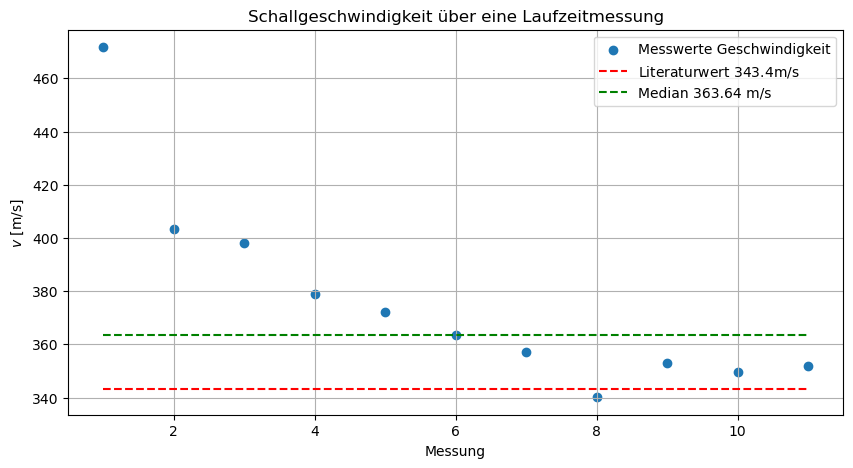

In [ ]:
# | fig-cap: Schallgeschwindigkeit über eine Laufzeitmessung
# | label: fig-schallgesch-ueber-laufzeitmess
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

daten = pd.read_csv("./daten/Aufgabe1e.csv")

abstand = daten["s [cm]"] * 10**(-2)
zeit = daten["t [us]"] * 10**(-6)

gesch = daten["v [m/s]"]

plt.figure(figsize=(10,5))
plt.scatter(np.linspace(1, 11, 11), gesch, label="Messwerte Geschwindigkeit")
plt.hlines(343.4, xmin=1, xmax=len(abstand), colors='r', linestyles='--', label="Literaturwert $343.4$m/s")
plt.hlines(np.median(gesch), xmin=1, xmax=len(abstand), colors='g', linestyles='--', label=f"Median {np.median(gesch)} m/s")
plt.title("Schallgeschwindigkeit über eine Laufzeitmessung")
plt.xlabel("Messung")
plt.ylabel("$v$ [m/s]")
plt.legend()
plt.grid()
plt.show()

## Allgemeine Fehlerbetrachtung
Für die allgemeine Fehlerbetrachtung, bleibt zu sagen, dass der exakte aufenthaltsort der Ultraschallsenders und -empfängers nicht bekannt war. Die Geräte waren insgesammt 3cm groß, es wurde in der Mitte dieser Geräte gemessen. Da der Sensor irgendwo in diesem Gerät ist, lässt sich sagen das die ganzen Abstände eine Abweichung von $\pm 1.5cm$ haben können, hinzu kommt die Abweichung beim Ablesen, da hierfür nur ein Lineal zustand welches eine Genauigkeit von 0.5mm hatte. Somit hatten wir beim Messen eine insgesammte Unsicherheit von
$$1.5008 \cdot 10^{-2}m \approx \sqrt{(1.5 \cdot 10^{-2}m)^2 + (0.5 \cdot 10^{-3}m)^2}$$
Zudem wie schon erwähnt, hatte das Voltmeter sehr starke Schwankungen mit bis zu $\pm 6 mV$ sowie das Oszilloskop auch verrauschte Daten angezeit hat, welches die Auswertung schwerer gemacht haben. Dennoch kann man wie unsere Ergebnisse zeigen, trotz dieser ganzen Unsicherheiten auf qualitativ gute Ergebnisse kommen, welche in der nähe der Literaturwerte liegen.